In [39]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

Loading dataset

In [ ]:
train_df = pd.read_csv('/Users/khursheedfatima/Documents/Projects/Predictive_Maintenance/data/CMaps/train_FD001.txt', sep='\s+', header=None)
train_df.columns = ['unit', 'cycle'] + [f'setting{i}' for i in range(1,4)] + [f'sensor{i}' for i in range(1,22)]

test_df = pd.read_csv('/Users/khursheedfatima/Documents/Projects/Predictive_Maintenance/data/CMaps/test_FD001.txt', sep='\s+', header=None)
test_df.columns = ['unit', 'cycle'] + [f'setting{i}' for i in range(1,4)] + [f'sensor{i}' for i in range(1,22)]

rul = pd.read_csv('/Users/khursheedfatima/Documents/Projects/Predictive_Maintenance/data/CMaps/RUL_FD001.txt',header=None)
rul.columns =['RUL']

Data Preprocessing

In [6]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
unit,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.0000,77.0000,100.0000
cycle,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
setting1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
setting2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
setting3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
sensor1,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
sensor2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
sensor3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
sensor4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
sensor5,20631.0,14.620000,1.776400e-15,14.6200,14.6200,14.6200,14.6200,14.6200


In [8]:
#checking train-test ratio 
print(f"Percentage of Testing Data: {len(test_df)/(len(train_df)+len(test_df)):.2%}")

Percentage of Testing Data: 38.83%


In [9]:
# Null values check
train_df.isnull().sum()

unit        0
cycle       0
setting1    0
setting2    0
setting3    0
sensor1     0
sensor2     0
sensor3     0
sensor4     0
sensor5     0
sensor6     0
sensor7     0
sensor8     0
sensor9     0
sensor10    0
sensor11    0
sensor12    0
sensor13    0
sensor14    0
sensor15    0
sensor16    0
sensor17    0
sensor18    0
sensor19    0
sensor20    0
sensor21    0
dtype: int64

Feature Engineering

In [10]:
# multiple sensors had 0 std -> that meant that they were constant, this mean that they provide no value, hence these sensors should be removed

# but std =0 isnt the best measure to do so, cuz in real life a sensor can have a very mintute std doesnt mean that they're not constant, hence we check the number of unique values

constant_features = [col for col in train_df.columns if train_df[col].nunique() <= 1]

# this is cuz std - sensitive to small numerical differnces, where nunique checks only whats written. (could use .std() after rounding to 5 decimals too)

constant_features

['setting3',
 'sensor1',
 'sensor5',
 'sensor10',
 'sensor16',
 'sensor18',
 'sensor19']

In [11]:
constant_features2 = [col for col in train_df.columns if train_df[col].std() ==0 ]
constant_features2

['setting3', 'sensor1', 'sensor10', 'sensor18', 'sensor19']

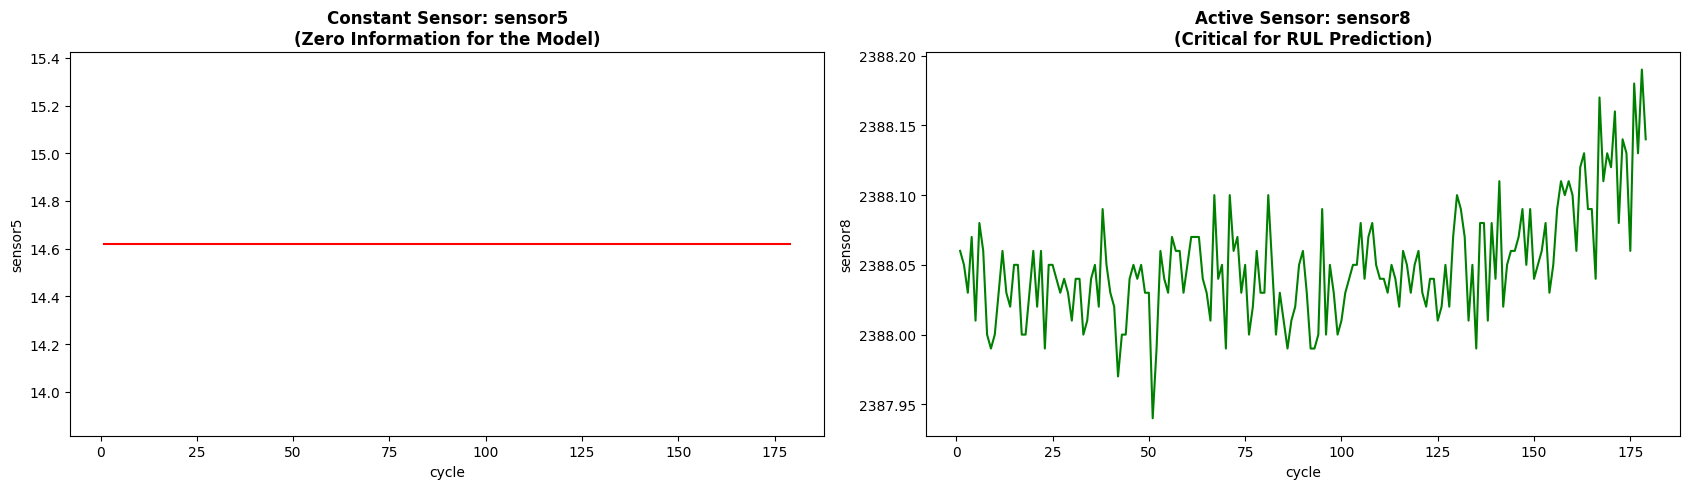

In [12]:
# we can clearly see the differnce between the two

# we can plot to figure out why std() failed
dead_sensor = 'sensor5'
active_sensor = 'sensor8'

fig, ax = plt.subplots(1, 2, figsize=(17, 5))

# Plot Dead Sensor
sns.lineplot(x='cycle', y=dead_sensor,
             data=train_df[train_df['unit'] == 3],
             ax=ax[0], color='r')
ax[0].set_title(
    f'Constant Sensor: {dead_sensor}\n(Zero Information for the Model)',
    fontweight='bold')

# Plot Active Sensor
sns.lineplot(x='cycle', y=active_sensor,
             data=train_df[train_df['unit'] == 3],
             ax=ax[1], color='g')
ax[1].set_title( f'Active Sensor: {active_sensor}\n(Critical for RUL Prediction)',
                 fontweight='bold')

plt.tight_layout()
plt.show()

In [13]:
train_df=train_df.drop(columns=constant_features)
test_df=test_df.drop(columns=constant_features)

In [14]:
# RUL calculation 
train_df['RUL'] = train_df.groupby('unit')['cycle'].transform(lambda x: x.max() - x)

In [15]:
train_df[['unit','cycle','RUL']].head()

,unit,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187


In [16]:
# RUL clipping 
# RUL > 125 → just call it 125
# RUL < 125 → keep real values

# this is done so that model detects when things start going bad, instead of predicitng large random numbers (since startign cycles hv that)

RUL_THRESHOLD = 125
train_df['RUL'] = train_df['RUL'].clip(upper=RUL_THRESHOLD)
print(f"RUL Clipping applied. Max RUL is now capped at {RUL_THRESHOLD} cycles.")
print("\nRUL Statistics after Clipping:")

train_df['RUL'].describe().T

RUL Clipping applied. Max RUL is now capped at 125 cycles.

RUL Statistics after Clipping:


count    20631.000000
mean        86.829286
std         41.673699
min          0.000000
25%         51.000000
50%        103.000000
75%        125.000000
max        125.000000
Name: RUL, dtype: float64

Exploratory Data Analysis (EDA)

In [ ]:
# survival analysis on how long do engines last
engine_lifespan = train_df.groupby('unit')['cycle'].max()
# this gives the lifespan = max cycle - for all units (grouped by unit)

print("Mean Lifespan:", engine_lifespan.mean())
print("Min Lifespan:", engine_lifespan.min())
print("Max Lifespan:", engine_lifespan.max())

# and now for all the max cycles possibel for all units, we cal its max, min and avg

Mean Lifespan: 206.31
Min Lifespan: 128
Max Lifespan: 362


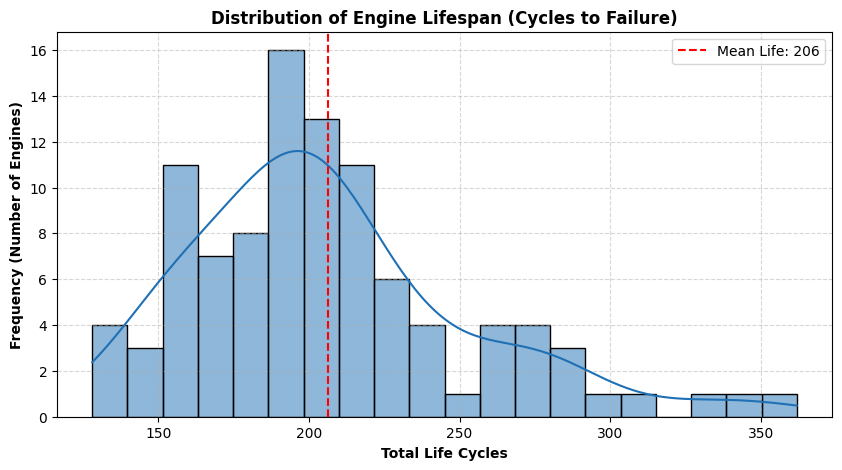

In [ ]:
# plotting distrubution 
# for every unit we're plotting their lifespan, but in a histplot-> so we get the distrubtion of lifespan among all the units (not RUL)
plt.figure(figsize=(10, 5))

sns.histplot(engine_lifespan, kde=True, color='#1f70b4', bins=20) #kde for smoother plot curve

plt.title('Distribution of Engine Lifespan (Cycles to Failure)', fontweight='bold', size=12)
plt.xlabel('Total Life Cycles', fontweight='bold', size=10)
plt.ylabel('Frequency (Number of Engines)', fontweight='bold', size=10)

plt.grid(True, linestyle='--', alpha=0.5) #grid
plt.axvline(engine_lifespan.mean(), color='r', linestyle='--', label=f'Mean Life: {int(engine_lifespan.mean())}') #mean line

plt.legend()
plt.show()

In [31]:
# the data is slightly rightskewed - kind of justifies why we needed the RUL clipping 

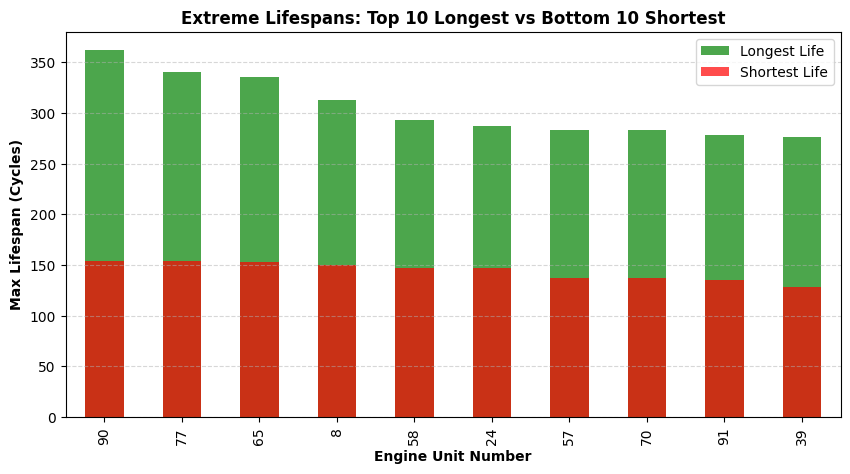

In [22]:
# Bar Chart (Extremes)
sorted_lifespan = engine_lifespan.sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sorted_lifespan.head(10).plot(kind='bar', color='green', alpha=0.7, label='Longest Life')
sorted_lifespan.tail(10).plot(kind='bar', color='red', alpha=0.7, label='Shortest Life')
plt.title('Extreme Lifespans: Top 10 Longest vs Bottom 10 Shortest', fontweight='bold', size=12)
plt.xlabel('Engine Unit Number', fontweight='bold')
plt.ylabel('Max Lifespan (Cycles)', fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.legend()
plt.show()

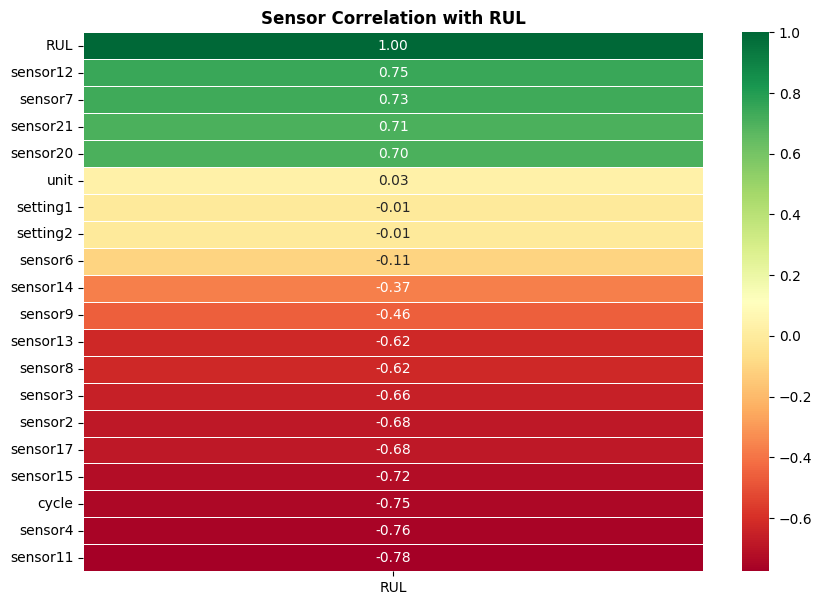

 Sensors with high positive or negative correlation are the most important predictors.


In [23]:
# Correlation Heatmap

# Which sensors correlate most strongly with RUL?
corr_matrix = train_df.corr()
rul_corr = corr_matrix['RUL'].sort_values(ascending=False).to_frame()

plt.figure(figsize=(10, 7))
sns.heatmap(rul_corr, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)
plt.title('Sensor Correlation with RUL', fontsize=12, fontweight='bold')
plt.show()

print(" Sensors with high positive or negative correlation are the most important predictors.")

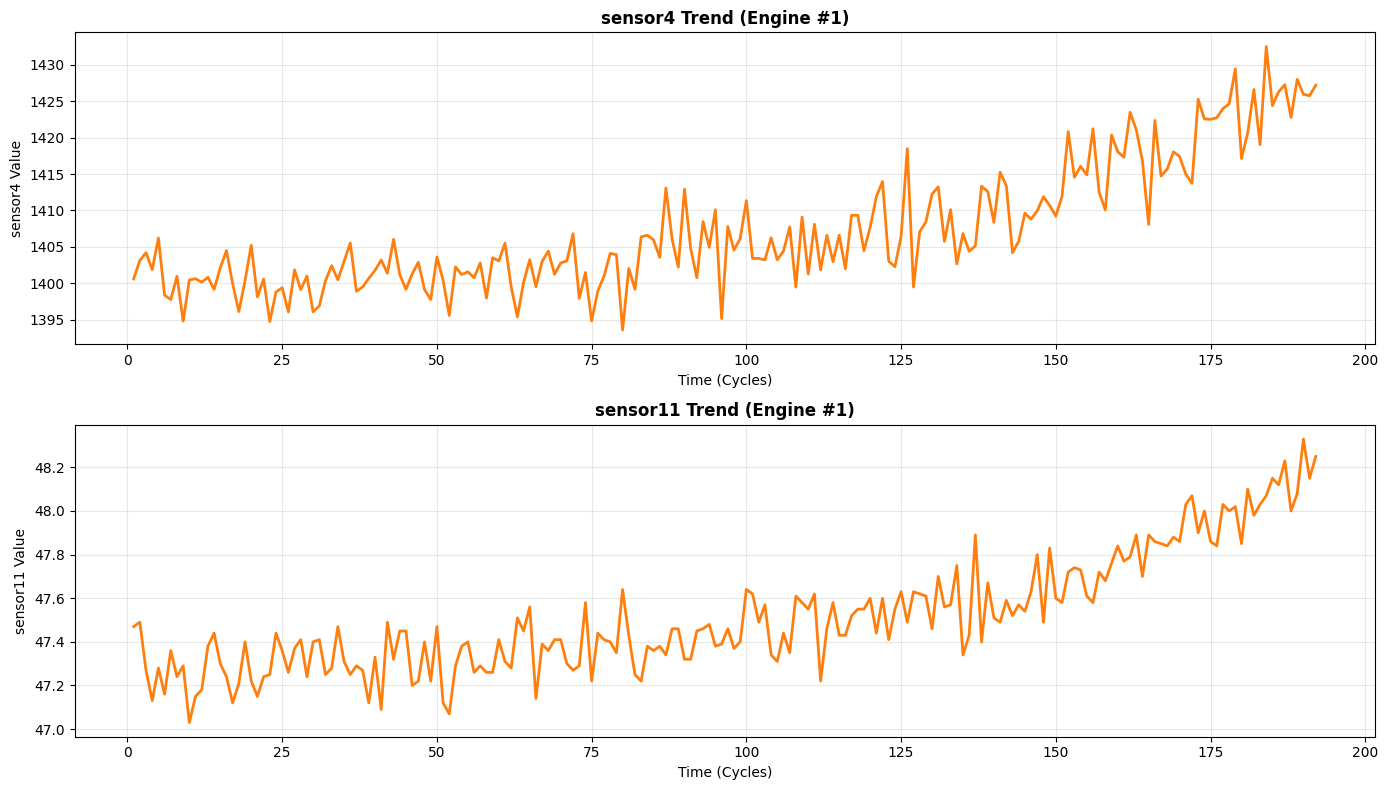

In [24]:
# visualsing the top correcated -> sensor4(.76) and sensor 11(.78)

top_sensors = ['sensor4', 'sensor11']
sample_unit = 1

fig, ax = plt.subplots(len(top_sensors), 1, figsize=(14, 8))

for i, sensor in enumerate(top_sensors):
    unit_data = train_df[train_df['unit'] == sample_unit]
    ax[i].plot(unit_data['cycle'], unit_data[sensor], color='#ff7f0e', linewidth=2)
    ax[i].set_title(f'{sensor} Trend (Engine #{sample_unit})', fontsize=12, fontweight='bold')
    ax[i].set_ylabel(f'{sensor} Value', fontsize=10)
    ax[i].set_xlabel('Time (Cycles)')
    ax[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

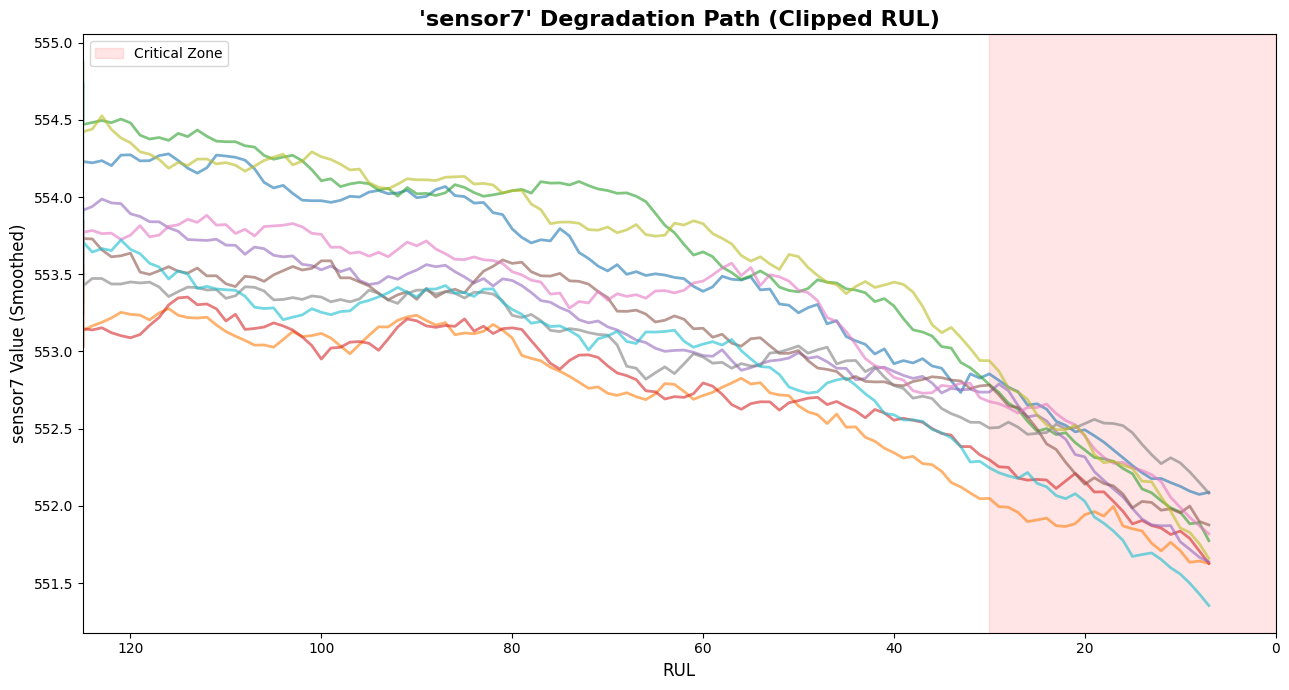

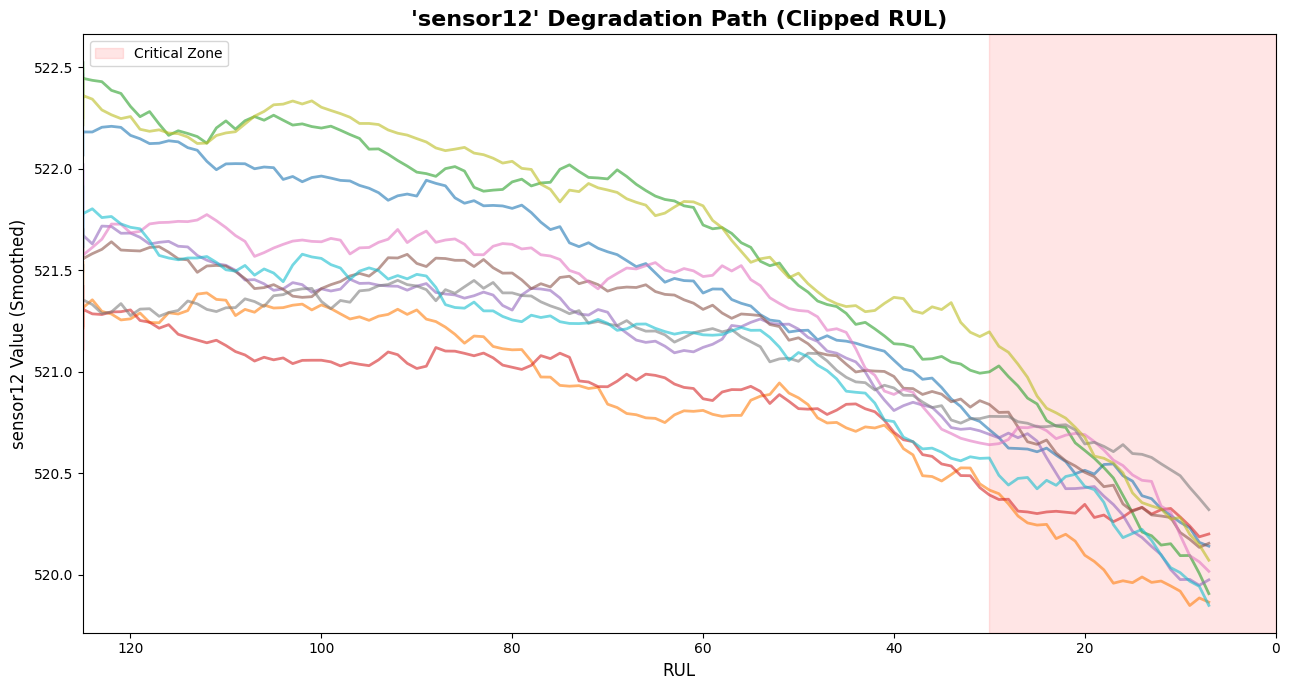

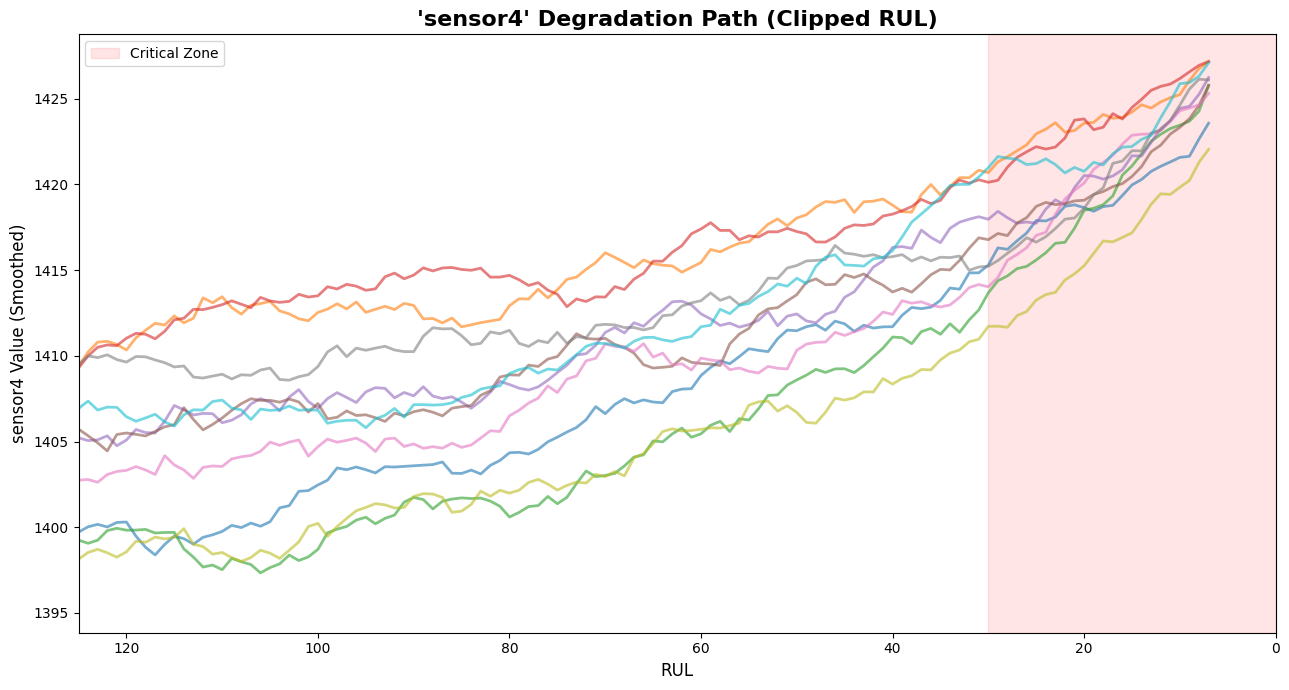

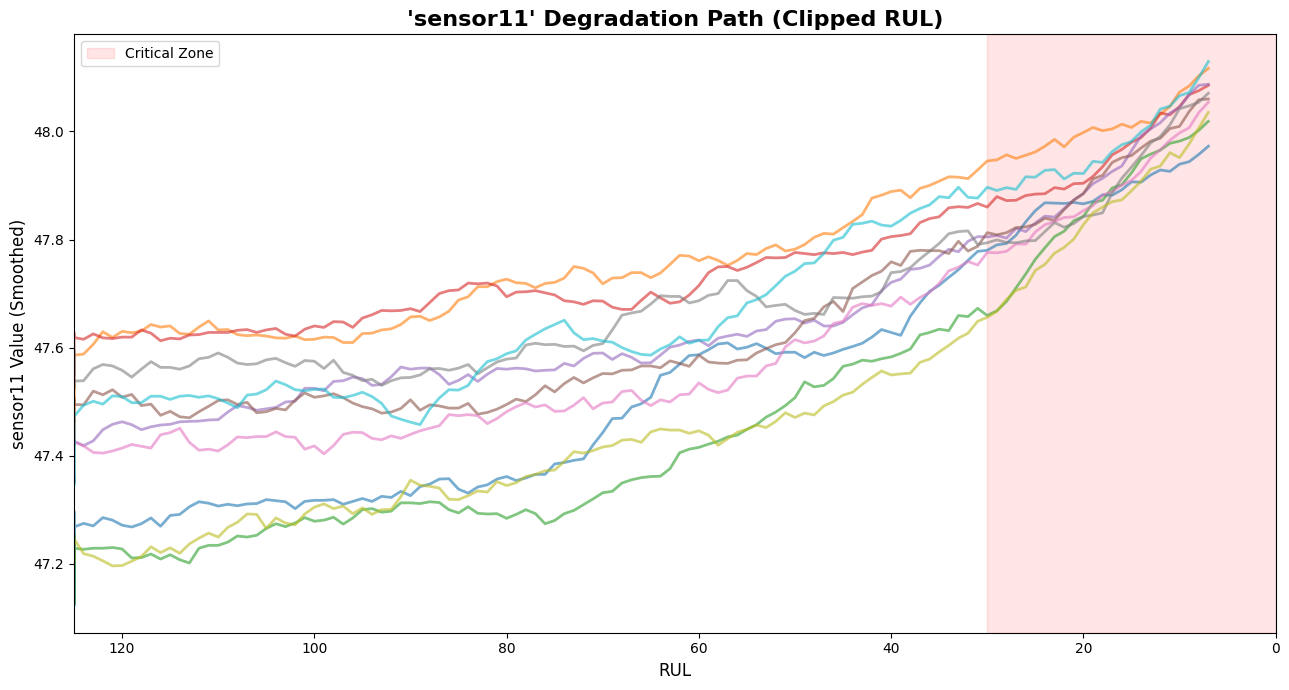

In [25]:
# this was for just one unit, now we'll try plotting a smoother curve for top 5 sensors, but not for all units but every 10th unit. the curve is smoothern using rolling mean- that takes an average of the window given in past. it tell hwo the trend has been instead of the current instance

def plot_engine_evolution_v2(df, sensor_name):
    if sensor_name not in df.columns:
        return
    plt.figure(figsize=(13, 7))

    # every 10th until
    units_to_plot = [u for u in df['unit'].unique() if u % 10 == 0]
    for unit in units_to_plot:
        unit_data = df[df['unit'] == unit]
    
        # appling rolling mean
        smoothed_signal = unit_data[sensor_name].rolling(window=15, center=True).mean()

        plt.plot(unit_data['RUL'], smoothed_signal, linewidth=2, alpha=0.6, label=f'Unit {unit}')

    plt.xlim(max(df['RUL']), 0) # Reverse X-axis (High RUL -> 0 RUL)
    plt.axvspan(30, 0, color='red', alpha=0.1, label='Critical Zone (<30 Cycles)')

    plt.title(f"'{sensor_name}' Degradation Path (Clipped RUL)", fontsize=16, fontweight='bold')
    plt.xlabel('RUL', fontsize=12)
    plt.ylabel(f'{sensor_name} Value (Smoothed)', fontsize=12)

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    if 'Critical Zone (<30 Cycles)' in by_label:
        plt.legend([by_label['Critical Zone (<30 Cycles)']], ['Critical Zone'], loc='upper left')
    plt.tight_layout()
    plt.show()

desired_sensors = ['sensor7', 'sensor12', 'sensor4', 'sensor11']
valid_sensors_to_plot = [s for s in desired_sensors if s in train_df.columns]

for sensor in valid_sensors_to_plot:
    plot_engine_evolution_v2(train_df, sensor)

In [72]:
# this visually represents how good these sensors are to test for critical zone of RUL 

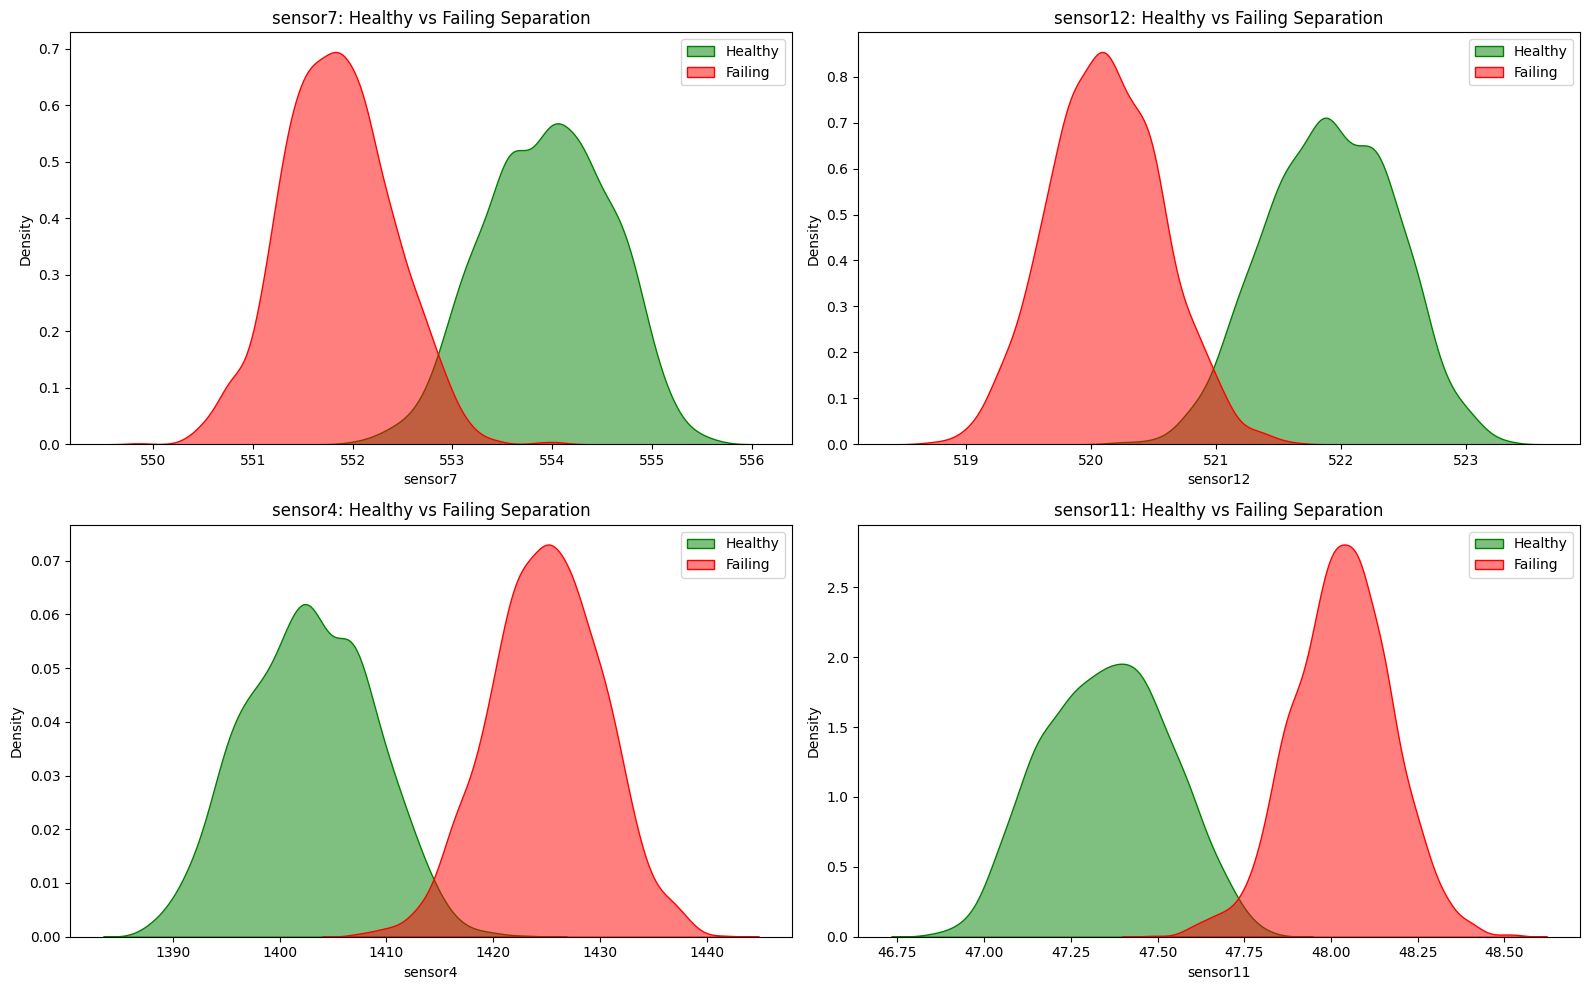

In [27]:
# ploting early engines and late ones to see the difference wrt to the 4 most imp params

early = train_df[train_df['cycle'] < 20]# First 20 cycles
late = train_df[train_df['RUL'] < 20]# Last 20 cycles

sensors_to_compare = ['sensor7', 'sensor12', 'sensor4', 'sensor11']
available_sensors = [s for s in sensors_to_compare if s in train_df.columns]

if available_sensors:
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))
    axes = axes.flatten()

    for i, sensor in enumerate(available_sensors):
        sns.kdeplot(early[sensor], fill=True, color="green", label='Healthy', ax=axes[i], alpha=0.5)
        sns.kdeplot(late[sensor], fill=True, color="red", label='Failing', ax=axes[i], alpha=0.5)
        axes[i].set_title(f'{sensor}: Healthy vs Failing Separation')
        axes[i].legend()
    plt.tight_layout()
    plt.show()


In [28]:
# can do PCA -but not doin right now

In [34]:
train_df2 = train_df.copy()
# backup df

Proprocessing Data

In [35]:
# Need to normalise/ scale down the data for ML models

In [ ]:
# Normalising using 

# not using unit - cuz leads to voerfitting (might learn for specific untis only)- this is jsut the id
# not using cycles - this will just leak the data if used wrongly

# 1. Feature engineering (rolling, lag using unit)
# 2. Drop NA (due to rolling/lag)
# 3. Prepare X, y (drop unit, handle cycle)
# 4. Scaling (based on model)
# 5. Apply SAME preprocessing to test data
# 6. Train models (LR → SVR → RF → XGB)
# 7. Evaluate (RMSE, MAE, R²)
# 8. Compare + analyze errors

# different feature engineering required for differnt models


Linear Regression

In [37]:
df = train_df.copy()

sensor_cols = [col for col in df.columns if col not in ['unit', 'cycle', 'RUL']]

# cal rolling mean (grouping based on unit)
for col in sensor_cols:
    df[f'{col}_rm'] = df.groupby('unit')[col].transform(lambda x: x.rolling(5).mean())

# need to dropna caused due to rm
df = df.dropna()

In [38]:
# splitting into X and y

train_X = df.drop(columns=['unit', 'cycle', 'RUL'])
train_y = df['RUL']

In [40]:
# scaling for LR 

scaler = StandardScaler()
train_X_scaled = scaler.fit_transform(train_X)

In [42]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(train_X_scaled, train_y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [45]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

y_pred = model.predict(train_X_scaled)

rmse = np.sqrt(mean_squared_error(train_y, y_pred))
mae = mean_absolute_error(train_y, y_pred)
r2 = r2_score(train_y, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

RMSE: 20.940312230077556
MAE: 17.064840493824754
R2: 0.748218403730136


In [49]:
test = test_df.copy()

# Rolling mean
for col in sensor_cols:
    test[f'{col}_rm'] = test.groupby('unit')[col].transform(lambda x: x.rolling(5).mean())

test = test.dropna()



In [50]:
train_X.shape



(20231, 34)

In [52]:
# Prepare X_test
X_test = test.drop(columns=['unit', 'cycle', 'RUL',], errors='ignore')

In [53]:
X_test.shape

(12696, 34)

In [54]:

# Scale using SAME scaler
X_test_scaled = scaler.transform(X_test)

# Predictions
y_test_pred = model.predict(X_test_scaled)

In [55]:
final_test = test.groupby('unit').tail(1)

X_final = final_test.drop(columns=['unit', 'cycle', 'RUL'], errors='ignore')
X_final_scaled = scaler.transform(X_final)

final_predictions = model.predict(X_final_scaled)

In [65]:
len(final_predictions) == len(rul)

True

In [66]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_true = rul['RUL'].values
y_pred = final_predictions

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("Test RMSE:", rmse)
print("Test MAE:", mae)
print("Test R2:", r2)

Test RMSE: 21.745923859416127
Test MAE: 17.289861295960122
Test R2: 0.7261604440199053


In [58]:
final_predictions.shape

(100,)

In [63]:
rul = pd.read_csv('/Users/khursheedfatima/Documents/Projects/Predictive_Maintenance/data/CMaps/RUL_FD001.txt',header=None)
rul.columns =['RUL']

In [61]:
final_predictions

array([125.77263533, 102.29575179,  73.27323913,  80.95316998,
        87.99262773,  99.17484251, 107.69553453,  81.12002597,
        98.48583074,  95.06083408,  87.32629729,  97.6103126 ,
        90.64846246,  95.35775227, 120.99734662, 110.7624378 ,
        68.77529919,  73.30696135,  94.69850846,  27.86191813,
        94.31309573, 110.89145583, 126.35616619,  32.86875024,
       112.80870005, 118.19590895, 104.45835176,  90.15180362,
        96.87221893,  85.97645428,  11.16120677,  77.8950485 ,
        86.64461198,  21.10817565,  11.03714452,  27.71493872,
        74.61595696,  54.69273653, 128.38797537,  42.49635511,
        74.4686243 ,  46.9074842 ,  71.3713046 , 101.14114537,
        67.08025172,  50.84828814,  97.46666733,  97.5838037 ,
        38.01065862, 102.07092284,  93.67120402,  58.16819219,
        44.44453586, 114.23451958, 111.30556564,  36.48681331,
        84.50335062,  63.59806601, 125.29042001,  92.13881691,
        50.34479827,  65.08622267,  74.27762645,  54.43